# Baseline: Official MedMNIST ResNet-50

This notebook documents the baseline reproduction pipeline. It loads saved artifacts from `results/baseline` and `models/baseline`; it does not retrain the model.

Reference target: MedMNIST v2 PathMNIST ResNet-50 at 28x28, AUC `0.990`, ACC `0.911`.

In [2]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RESULT_DIR = Path('../results/baseline')
metrics_path = RESULT_DIR / 'metrics.json'
if not metrics_path.exists():
    raise FileNotFoundError('Run the baseline training command from data/experiment-design.md first.')
metrics = json.loads(metrics_path.read_text())
test = metrics['test']
pd.Series({k: v for k, v in test.items() if isinstance(v, (int, float))})

auc                   0.990435
acc                   0.911142
precision_macro       0.870790
recall_macro          0.875577
specificity_macro     0.989062
f1_macro              0.870102
f2_macro              0.872685
cancer_precision      0.940050
cancer_recall         0.915653
cancer_specificity    0.987893
cancer_f1             0.927691
cancer_f2             0.920430
dtype: float64

In [3]:
target = metrics.get('target', {})
print('Target:', target)
print('Passed baseline gate:', target.get('passed', False))

Target: {'auc': {'target': 0.99, 'actual': 0.9904349002844827, 'passed': True}, 'acc': {'target': 0.911, 'actual': 0.911142061281337, 'passed': True}, 'passed': True}
Passed baseline gate: True


## Cancer-Related Class F2 Scores

The main project target is the F2 score for colorectal adenocarcinoma epithelium, the actual cancer class. For comparison, the table below also reports the one-vs-rest F2 score for cancer-associated stroma.


In [4]:
class_names = [
    name for name in test['classification_report'].keys()
    if name not in {'accuracy', 'macro avg', 'weighted avg'}
]
cm = np.asarray(test['confusion_matrix'])

def one_vs_rest_fbeta_from_cm(cm, class_index, beta=2):
    tp = cm[class_index, class_index]
    fp = cm[:, class_index].sum() - tp
    fn = cm[class_index, :].sum() - tp
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    beta_sq = beta ** 2
    denom = beta_sq * precision + recall
    fbeta = (1 + beta_sq) * precision * recall / denom if denom else 0.0
    return {'precision': precision, 'recall': recall, f'f{beta}': fbeta}

f2_rows = []
for class_name in ['cancer-associated stroma', 'colorectal adenocarcinoma epithelium']:
    class_index = class_names.index(class_name)
    row = {'class': class_name}
    row.update(one_vs_rest_fbeta_from_cm(cm, class_index, beta=2))
    f2_rows.append(row)

pd.DataFrame(f2_rows)


,class,precision,recall,f2
0,cancer-associated stroma,0.664474,0.479810,0.508048
1,colorectal adenocarcinoma epithelium,0.940050,0.915653,0.920430


In [3]:
pd.DataFrame(test['confusion_matrix'])

,0,1,2,3,4,5,6,7,8
0,1326,5,1,0,2,3,0,0,1
1,0,847,0,0,0,0,0,0,0
2,0,0,279,1,0,18,1,40,0
3,0,0,2,629,0,0,1,0,2
4,54,14,1,0,947,1,5,10,3
5,0,0,40,0,15,492,0,45,0
6,0,2,3,12,4,0,691,1,28
7,0,0,79,3,1,95,3,202,38
8,0,0,25,25,4,8,36,6,1129


## Baseline Confusion Matrix

Rows show the true PathMNIST class and columns show the predicted class. The heatmap visualizes the test-set confusion matrix for the saved baseline model.


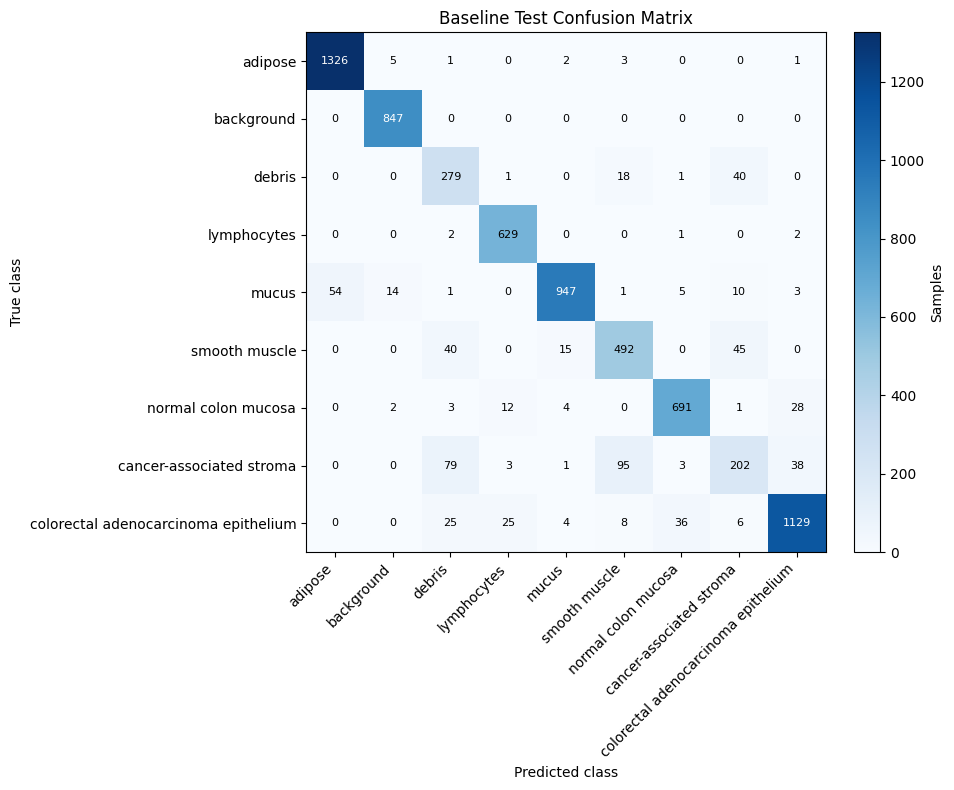

In [5]:
class_names = [
    name for name in test['classification_report'].keys()
    if name not in {'accuracy', 'macro avg', 'weighted avg'}
]
cm = np.asarray(test['confusion_matrix'])

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, cmap='Blues')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Samples')

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_yticklabels(class_names)
ax.set_xlabel('Predicted class')
ax.set_ylabel('True class')
ax.set_title('Baseline Test Confusion Matrix')

threshold = cm.max() * 0.55
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = 'white' if cm[i, j] > threshold else 'black'
        ax.text(j, i, int(cm[i, j]), ha='center', va='center', color=color, fontsize=8)

fig.tight_layout()
plt.show()


## Interpretability of the Baseline CNN

This section analyzes the saved baseline CNN as a model inspection report. The main question is why the baseline performs weakly on **cancer-associated stroma** while still performing well on the actual cancer class, **colorectal adenocarcinoma epithelium**.

The interpretation is split into three parts:

1. **Confidence analysis:** how strongly the model believes its own predictions for stroma-related cases.
2. **Layer feature maps:** which internal feature maps activate in early, middle, and deep CNN layers.
3. **Grad-CAM overlays:** which image regions most influence selected class logits.

The plots are saved as SVG files under `report/figures` so they can be reused in the LaTeX report.


### Research Context

The research notes suggest that interpretability matters here because PathMNIST is not just a class-frequency problem. The difficult cases are visually adjacent tissue patterns and operating-point decisions.

The most relevant papers and findings mentioned in `data/research.md` and `data/combining_classifiers_research.md` are:

- **Kather et al. source study:** establishes the colorectal tissue classification task and external validation setting. It motivates looking at class-specific failure modes instead of only overall accuracy.
- **Official MedMNIST / MedMNIST+ benchmarks:** emphasize AUC and accuracy, but the notes point out that those metrics do not explain which tissue classes are confused or whether a chosen operating point is clinically acceptable.
- **Halder et al. ViT PathMNIST study:** reports class-wise results and shows that tumor-related errors concentrate in specific neighboring tissue classes. This supports inspecting confusion neighborhoods rather than treating all non-cancer classes as one uniform background.
- **Failure-detection and uncertainty work on PathMNIST:** motivates inspecting model confidence, because a wrong but high-confidence prediction is more dangerous than a wrong prediction that is visibly uncertain.
- **HistoSSL and pathology-specific representation work:** motivates looking at learned feature maps at multiple levels, because histology classifiers can learn stain, cell, and tissue-structure cues rather than a single human-readable feature.
- **Risk-aware / cost-sensitive PathMNIST work:** motivates separating recall-oriented cancer detection from ordinary multiclass accuracy, especially when false negatives are clinically costly.

The visualizations below should therefore be read as diagnostic evidence. They do not prove biological correctness, but they show how the trained baseline behaves on the exact saved test predictions.


In [6]:
import sys
import torch
import torch.nn.functional as F

PROJECT_ROOT = Path('..').resolve()
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from pathmnist.data import PATHMNIST_MEAN, PATHMNIST_STD, build_dataset, dataset_meta
from pathmnist.models import build_model

FIGURE_DIR = PROJECT_ROOT / 'report' / 'figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

predictions = np.load(RESULT_DIR / 'test_predictions.npz')
y_true = predictions['y_true'].reshape(-1).astype(int)
y_prob = predictions['y_prob'].astype(float)
y_pred = y_prob.argmax(axis=1)
y_conf = y_prob.max(axis=1)

class_names = [
    name for name in test['classification_report'].keys()
    if name not in {'accuracy', 'macro avg', 'weighted avg'}
]
class_to_index = {name: idx for idx, name in enumerate(class_names)}

STROMA = class_to_index['cancer-associated stroma']
CANCER = class_to_index['colorectal adenocarcinoma epithelium']
DEBRIS = class_to_index['debris']
SMOOTH = class_to_index['smooth muscle']
MUCUS = class_to_index['mucus']
NORMAL = class_to_index['normal colon mucosa']

relevant_classes = [DEBRIS, SMOOTH, STROMA, CANCER]
relevant_names = [class_names[idx] for idx in relevant_classes]
short_names = {
    DEBRIS: 'debris',
    SMOOTH: 'smooth muscle',
    STROMA: 'cancer-associated stroma',
    CANCER: 'colorectal adenocarcinoma epithelium',
}

print({'n_test': int(len(y_true)), 'n_true_stroma': int(np.sum(y_true == STROMA))})


{'n_test': 7180, 'n_true_stroma': 421}


/Users/nick/Workspace/pathmnist-classification-improvement/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Confidence on Stroma-Relevant Predictions

The table below answers the confidence question directly for **true cancer-associated stroma** samples. It groups those samples by the class the baseline predicted. The `mean_predicted_probability` and `median_predicted_probability` columns show whether the model made those predictions weakly or strongly.

This matters because the stroma F2 score is low for two different reasons:

- Many true stroma samples are sent to neighboring non-cancer classes, especially debris and smooth muscle.
- Some of these errors are made with moderate to high confidence, which means they are not all simple low-confidence borderline cases.


In [7]:
confidence_rows = []
for pred_class in relevant_classes:
    mask = (y_true == STROMA) & (y_pred == pred_class)
    if not np.any(mask):
        continue
    confidence_rows.append({
        'true_class': class_names[STROMA],
        'predicted_class': class_names[pred_class],
        'n': int(mask.sum()),
        'mean_predicted_probability': float(y_conf[mask].mean()),
        'median_predicted_probability': float(np.median(y_conf[mask])),
        'mean_stroma_probability': float(y_prob[mask, STROMA].mean()),
        'mean_cancer_probability': float(y_prob[mask, CANCER].mean()),
    })

confidence_table = pd.DataFrame(confidence_rows)
confidence_table


,true_class,predicted_class,n,mean_predicted_probability,median_predicted_probability,mean_stroma_probability,mean_cancer_probability
0,cancer-associated stroma,debris,79,0.609271,0.621049,0.119530,0.084321
1,cancer-associated stroma,smooth muscle,95,0.712253,0.699615,0.176512,0.026845
2,cancer-associated stroma,cancer-associated stroma,202,0.699174,0.730848,0.699174,0.040726
3,cancer-associated stroma,colorectal adenocarcinoma epithelium,38,0.535248,0.522868,0.141539,0.535248


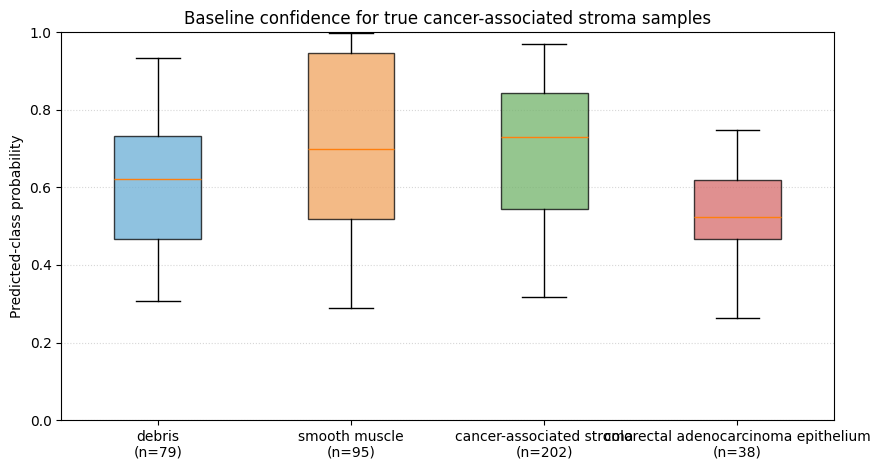

In [8]:
plot_data = []
plot_labels = []
for pred_class in relevant_classes:
    mask = (y_true == STROMA) & (y_pred == pred_class)
    if np.any(mask):
        plot_data.append(y_conf[mask])
        plot_labels.append(f'{short_names[pred_class]}\n(n={mask.sum()})')

fig, ax = plt.subplots(figsize=(9, 4.8))
box = ax.boxplot(plot_data, tick_labels=plot_labels, patch_artist=True, showfliers=False)
for patch, color in zip(box['boxes'], ['#6aaed6', '#f0a35e', '#72b36a', '#d66b6b']):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_ylabel('Predicted-class probability')
ax.set_ylim(0, 1)
ax.set_title('Baseline confidence for true cancer-associated stroma samples')
ax.grid(axis='y', linestyle=':', alpha=0.5)
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'baseline_stroma_confidence.svg', bbox_inches='tight')
plt.show()


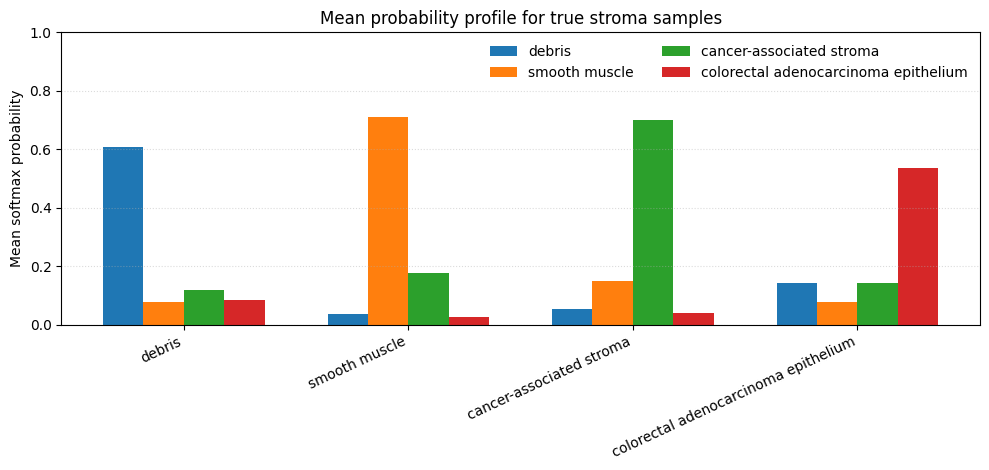

In [9]:
profile_rows = []
for pred_class in relevant_classes:
    mask = (y_true == STROMA) & (y_pred == pred_class)
    if not np.any(mask):
        continue
    for prob_class in relevant_classes:
        profile_rows.append({
            'predicted_group': short_names[pred_class],
            'probability_class': short_names[prob_class],
            'mean_probability': float(y_prob[mask, prob_class].mean()),
        })
profile_df = pd.DataFrame(profile_rows)

x = np.arange(len([short_names[idx] for idx in relevant_classes if np.any((y_true == STROMA) & (y_pred == idx))]))
probability_classes = relevant_classes
bar_width = 0.18
fig, ax = plt.subplots(figsize=(10, 4.8))
group_names = [short_names[idx] for idx in relevant_classes if np.any((y_true == STROMA) & (y_pred == idx))]
for offset_idx, prob_class in enumerate(probability_classes):
    values = []
    for group_name in group_names:
        value = profile_df[
            (profile_df['predicted_group'] == group_name)
            & (profile_df['probability_class'] == short_names[prob_class])
        ]['mean_probability'].iloc[0]
        values.append(value)
    ax.bar(x + (offset_idx - 1.5) * bar_width, values, width=bar_width, label=short_names[prob_class])

ax.set_xticks(x)
ax.set_xticklabels(group_names, rotation=25, ha='right')
ax.set_ylabel('Mean softmax probability')
ax.set_ylim(0, 1)
ax.set_title('Mean probability profile for true stroma samples')
ax.legend(frameon=False, ncols=2)
ax.grid(axis='y', linestyle=':', alpha=0.45)
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'baseline_stroma_probability_profiles.svg', bbox_inches='tight')
plt.show()


### Representative Stroma Cases

The next figure shows concrete test-set examples from the most important stroma-related outcomes. Each title reports the true class, the predicted class, and the model's top three probabilities. This connects the numeric confidence analysis back to actual image patches.


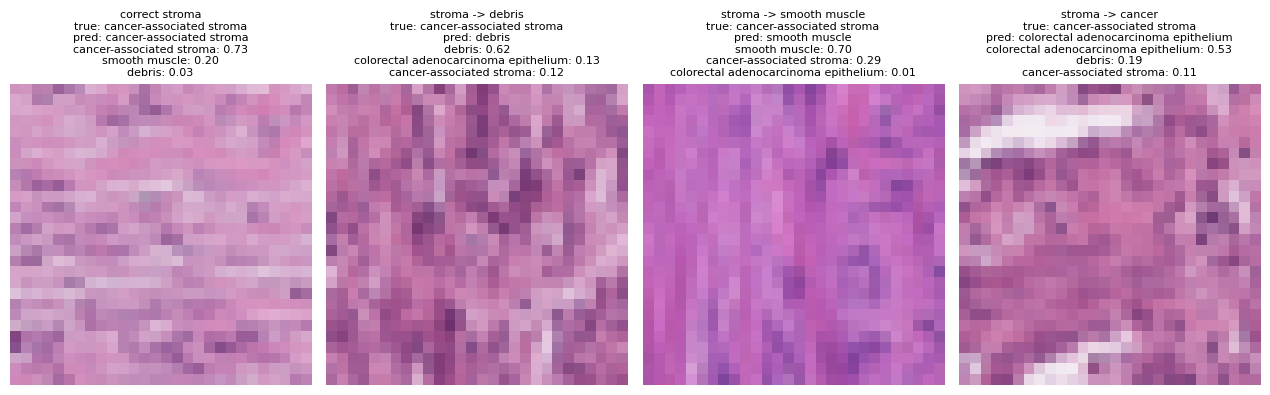

In [10]:
test_dataset = build_dataset(
    'test',
    image_size=28,
    source_size=None,
    augment='none',
    root=str(PROJECT_ROOT / 'data'),
    norm='pathmnist',
)

mean = torch.tensor(PATHMNIST_MEAN).view(3, 1, 1)
std = torch.tensor(PATHMNIST_STD).view(3, 1, 1)

def image_to_numpy(x_tensor):
    image = (x_tensor.cpu() * std + mean).clamp(0, 1)
    return image.permute(1, 2, 0).numpy()

def select_case(true_class, predicted_class, prefer='median_confidence'):
    candidates = np.where((y_true == true_class) & (y_pred == predicted_class))[0]
    if len(candidates) == 0:
        return None
    if prefer == 'highest_confidence':
        return int(candidates[np.argmax(y_conf[candidates])])
    median_conf = np.median(y_conf[candidates])
    return int(candidates[np.argmin(np.abs(y_conf[candidates] - median_conf))])

def top_prob_text(index, top_k=3):
    top = np.argsort(y_prob[index])[::-1][:top_k]
    return '\n'.join(f'{class_names[i]}: {y_prob[index, i]:.2f}' for i in top)

case_specs = [
    ('correct stroma', STROMA, STROMA),
    ('stroma -> debris', STROMA, DEBRIS),
    ('stroma -> smooth muscle', STROMA, SMOOTH),
    ('stroma -> cancer', STROMA, CANCER),
]
case_indices = []
for label, true_class, predicted_class in case_specs:
    index = select_case(true_class, predicted_class)
    if index is not None:
        case_indices.append((label, index))

fig, axes = plt.subplots(1, len(case_indices), figsize=(3.2 * len(case_indices), 3.8))
axes = np.asarray(axes).reshape(-1)
for ax, (label, index) in zip(axes, case_indices):
    x_tensor, _ = test_dataset[index]
    ax.imshow(image_to_numpy(x_tensor))
    ax.axis('off')
    ax.set_title(
        f'{label}\ntrue: {class_names[y_true[index]]}\npred: {class_names[y_pred[index]]}\n{top_prob_text(index)}',
        fontsize=8,
    )
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'baseline_stroma_representative_cases.svg', bbox_inches='tight')
plt.show()


### Layer-Level Feature Maps

A CNN learns feature maps rather than explicit human-written rules. The baseline architecture has convolutional blocks that can be inspected at increasing depths:

- **Early layer:** mostly local color contrast, stain intensity, borders, and simple edge-like responses.
- **Middle layer:** more structured local texture responses, such as repeated tissue fragments or gland-like boundaries.
- **Deep layer:** more class-specific combinations of texture and morphology, but at lower spatial resolution.

The figure below visualizes the most active channels from three representative activation layers for a stroma sample that the model misclassifies. The channel titles are not semantic labels; they are internal filters ranked by mean activation.


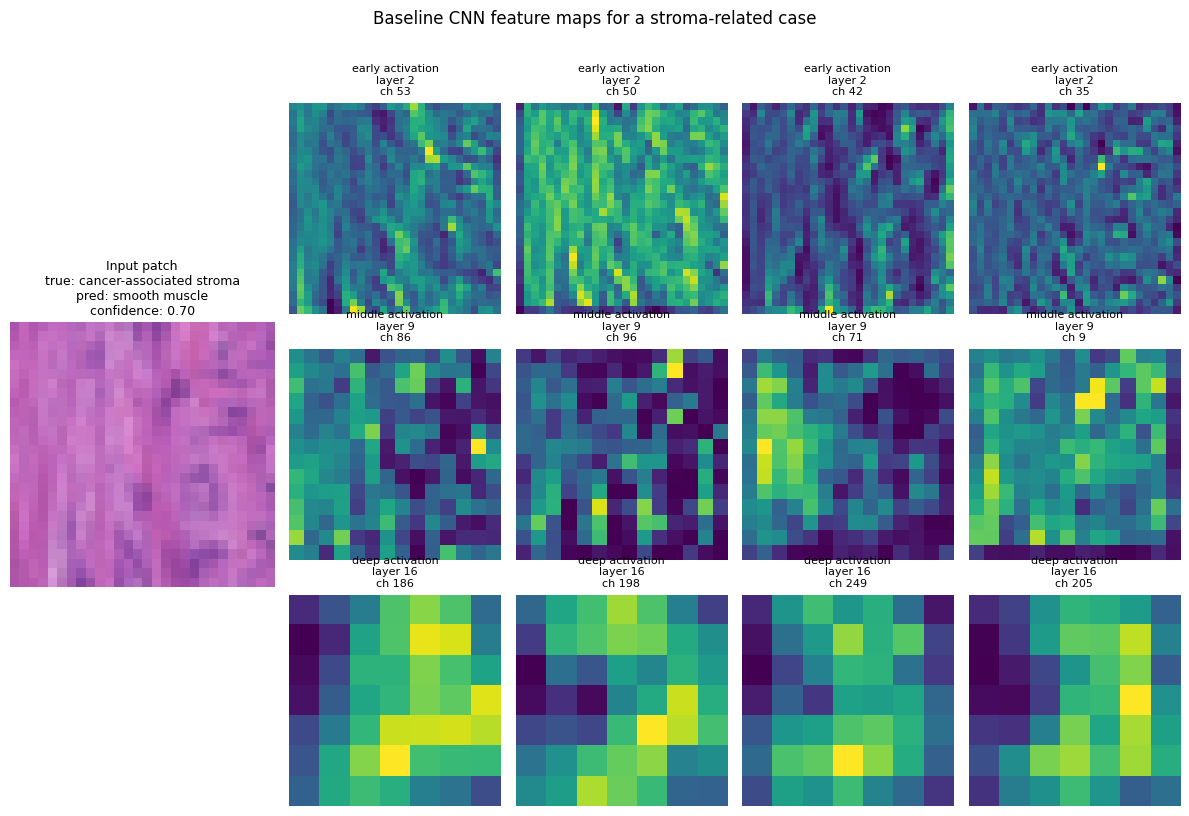

In [11]:
device = torch.device('cpu')
meta = dataset_meta()
baseline_model = build_model('small_cnn', meta.n_classes, pretrained=False).to(device)
checkpoint = torch.load(PROJECT_ROOT / 'models' / 'baseline' / 'best.pt', map_location=device)
baseline_model.load_state_dict(checkpoint['model'])
baseline_model.eval()

layer_case_index = select_case(STROMA, SMOOTH)
if layer_case_index is None:
    layer_case_index = select_case(STROMA, DEBRIS)
if layer_case_index is None:
    layer_case_index = select_case(STROMA, STROMA)

x_layer, _ = test_dataset[layer_case_index]
x_layer = x_layer.to(device)

feature_layers = {
    'early activation\nlayer 2': baseline_model.net[2],
    'middle activation\nlayer 9': baseline_model.net[9],
    'deep activation\nlayer 16': baseline_model.net[16],
}
activations = {}
hooks = []
for layer_name, layer in feature_layers.items():
    hooks.append(layer.register_forward_hook(
        lambda module, inputs, output, name=layer_name: activations.__setitem__(name, output.detach().cpu())
    ))

with torch.no_grad():
    logits = baseline_model(x_layer.unsqueeze(0))
    layer_probabilities = torch.softmax(logits, dim=1).squeeze().cpu().numpy()

for hook in hooks:
    hook.remove()

fig = plt.figure(figsize=(12, 8))
grid = fig.add_gridspec(3, 5, width_ratios=[1.25, 1, 1, 1, 1])
input_ax = fig.add_subplot(grid[:, 0])
input_ax.imshow(image_to_numpy(x_layer))
input_ax.axis('off')
input_ax.set_title(
    f'Input patch\ntrue: {class_names[y_true[layer_case_index]]}\n'
    f'pred: {class_names[y_pred[layer_case_index]]}\n'
    f'confidence: {y_conf[layer_case_index]:.2f}',
    fontsize=9,
)

for row, (layer_name, activation) in enumerate(activations.items()):
    maps = activation.squeeze(0)
    scores = maps.flatten(1).mean(dim=1)
    top_indices = torch.topk(scores, k=min(4, maps.shape[0])).indices.tolist()
    for col, channel_idx in enumerate(top_indices, start=1):
        ax = fig.add_subplot(grid[row, col])
        ax.imshow(maps[channel_idx].numpy(), cmap='viridis')
        ax.axis('off')
        ax.set_title(f'{layer_name}\nch {channel_idx}', fontsize=8)

fig.suptitle('Baseline CNN feature maps for a stroma-related case', y=1.02)
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'baseline_stroma_feature_maps.svg', bbox_inches='tight')
plt.show()


### Grad-CAM: Where the Baseline Looks

Feature maps show internal activations, but they do not directly answer which image regions influence a class score. Grad-CAM gives a coarser spatial explanation by weighting the last convolutional feature map with the gradient of a target class logit.

For each selected test patch below, the middle panel shows the heatmap for the **stroma logit** and the right panel shows the heatmap for the **predicted-class logit**. If the predicted-class heatmap differs strongly from the stroma heatmap, that suggests the model is using evidence for a competing tissue class rather than simply being uncertain.


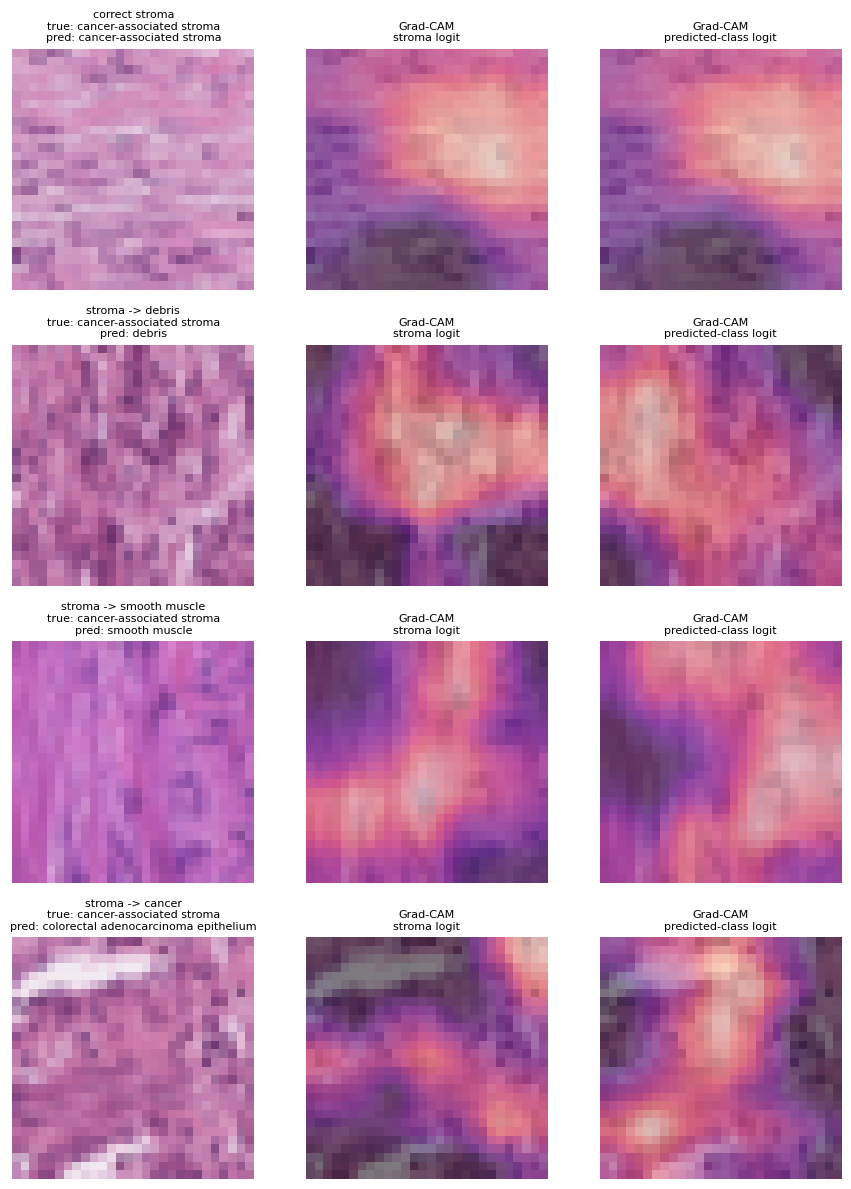

In [12]:
def baseline_grad_cam(model, x_tensor, target_class, target_layer_index=16):
    model.eval()
    model.zero_grad(set_to_none=True)

    z = x_tensor.unsqueeze(0).to(device)
    target_activation = None
    for layer_index, layer in enumerate(model.net):
        z = layer(z)
        if layer_index == target_layer_index:
            target_activation = z.clone()
            target_activation.retain_grad()
            z = target_activation

    logits = model.head(z)
    score = logits[0, target_class]
    score.backward()

    activation = target_activation.detach()
    gradient = target_activation.grad.detach()
    weights = gradient.mean(dim=(2, 3), keepdim=True)
    cam = (weights * activation).sum(dim=1, keepdim=True)
    cam = F.relu(cam)
    cam = F.interpolate(cam, size=x_tensor.shape[-2:], mode='bilinear', align_corners=False)
    cam = cam.squeeze().cpu().numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-12)
    probabilities = torch.softmax(logits.detach(), dim=1).squeeze().cpu().numpy()
    return cam, probabilities

cam_cases = case_indices[:4]
fig, axes = plt.subplots(len(cam_cases), 3, figsize=(9, 3.0 * len(cam_cases)))
axes = np.asarray(axes).reshape(len(cam_cases), 3)

for row, (case_label, index) in enumerate(cam_cases):
    x_tensor, _ = test_dataset[index]
    x_tensor = x_tensor.to(device)
    image_np = image_to_numpy(x_tensor)
    predicted_class = int(y_pred[index])

    stroma_cam, _ = baseline_grad_cam(baseline_model, x_tensor, target_class=STROMA)
    predicted_cam, _ = baseline_grad_cam(baseline_model, x_tensor, target_class=predicted_class)

    axes[row, 0].imshow(image_np)
    axes[row, 0].set_title(
        f'{case_label}\ntrue: {class_names[y_true[index]]}\npred: {class_names[predicted_class]}',
        fontsize=8,
    )
    axes[row, 0].axis('off')

    axes[row, 1].imshow(image_np)
    axes[row, 1].imshow(stroma_cam, cmap='magma', alpha=0.48)
    axes[row, 1].set_title('Grad-CAM\nstroma logit', fontsize=8)
    axes[row, 1].axis('off')

    axes[row, 2].imshow(image_np)
    axes[row, 2].imshow(predicted_cam, cmap='magma', alpha=0.48)
    axes[row, 2].set_title('Grad-CAM\npredicted-class logit', fontsize=8)
    axes[row, 2].axis('off')

fig.tight_layout()
fig.savefig(FIGURE_DIR / 'baseline_stroma_gradcam_cases.svg', bbox_inches='tight')
plt.show()


### Interpretation Summary

The baseline's low F2 for cancer-associated stroma is not explained by one simple failure mode. The confidence analysis and the confusion matrix show that true stroma samples are often split across **debris**, **smooth muscle**, and **colorectal adenocarcinoma epithelium**. The smooth-muscle errors are especially important because the model can make those predictions with fairly high confidence rather than treating them as obvious borderline cases.

The layer visualizations show the expected CNN hierarchy. Early channels respond to small local stain and edge patterns. Middle channels respond to larger tissue textures. Deep channels are sparse and more class-specific, which is useful for classification but harder to map cleanly onto human pathology terms. Because the input is only `28 x 28`, all spatial explanations are coarse: a highlighted region often covers a substantial part of the patch.

The Grad-CAM overlays are most useful for comparing competing explanations. When a true stroma image is predicted as smooth muscle or debris, the predicted-class heatmap can emphasize regions that differ from the stroma heatmap. That supports the conclusion from the literature review: PathMNIST errors are often **neighboring-tissue errors**, not random class mistakes. For the LaTeX report, the most defensible wording is that these visualizations provide model-diagnostic evidence of where the CNN attends, not clinical proof that the highlighted region is biologically causal.
